In [5]:
# ===== Robust Alpha Vantage loader + CHF risk functions =====

import os, io, time, json, hashlib, pathlib
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
import time
import re
from urllib.parse import urlparse
import matplotlib.pyplot as plt

load_dotenv()

EOD_API = os.getenv("EOD_API")

# --- guard API ticker early ---
if not EOD_API or not isinstance(EOD_API, str):
    raise RuntimeError(
        "one or more api kays not found")

CACHE_DIR = pathlib.Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

today = time.strftime("%Y-%m-%d")
START = '2020-01-01'  # global start date for all fetches

# Module-level debug flag (no new function args). Set RISK_DEBUG=1 in env to enable verbose diagnostics.
DEBUG = True

In [6]:
def _cache_path( ticker: str) -> pathlib.Path:
    safe_ticker = ticker.replace("/", "_").replace(":", "_").replace(" ", "_")
    fname = f"{safe_ticker}.csv"
    return CACHE_DIR / fname

def _is_fresh(path: pathlib.Path, max_age: int) -> bool:
    if not path.exists():
        print(f"Cache file {path} does not exist")
        return False
    age_hours = (time.time() - path.stat().st_mtime) / 3600
    # print(f"Cache file {path} age: {age_hours:.2f} hours (max age {max_age} hours)")
    result = age_hours <= max_age
    return result

def _looks_like_json(payload: bytes) -> bool:
    return payload.lstrip()[:1] in (b"{", b"[")

def fetch_csv_robust(url: str, params: dict, ticker: str, max_age: int = 24) -> pd.DataFrame:
    """
        Robust CSV fetch with:
      - on-disk cache (TTL),
      - JSON throttle/error detection (does NOT overwrite cache),
      - atomic write on success.
        Returns a parsed DataFrame (index on first column).
        """
    def check_start_date(df):
        earliest = df.index.min().date()
        # print('data start date:', earliest)
        # print('required START:', START)
        gap = (earliest - pd.to_datetime(START).date()).days
        # print('gap days:', gap)

        # if gap != 0:
        #     print('required START:', START,'\ndata start:', earliest)
        if gap > 5:
            print(f"WARNING: {ticker} data starts at {earliest}, after global start {START}")
    # print(f'params: {params}')
    path = _cache_path( ticker)

    # if cache is fresh return it
    if _is_fresh(path, max_age):
        print(f"{ticker} - using cached data")
        df = pd.read_csv(path, header=0, parse_dates=[0], index_col=0).sort_index()
        check_start_date(df)
        return df
    print(f"{ticker} - downloading fresh data")
    resp = requests.get(url, params=params)
        
    resp.raise_for_status()
    raw = resp.content


    # Detect JSON throttle/error; do not poison cache
    if _looks_like_json(raw):
        # Try to show a concise message
        try:
            msg = json.loads(raw.decode("utf-8", errors="ignore"))
        except Exception:
            msg = {"body_head": raw[:200].decode("utf-8", errors="ignore")}
        raise RuntimeError(f"... returned JSON (throttle/error) for :{ticker} -> {str(msg)[:180]}")

    # Parse CSV and normalize
    df = pd.read_csv(io.BytesIO(raw), header=0, parse_dates=[0], index_col=0).sort_index()
    check_start_date(df)
    print('saving ', path)
    # Atomic-ish write
    tmp = path.with_suffix(".tmp")
    with open(tmp, "wb") as f:
        f.write(raw)
    os.replace(tmp, path)
    return df

def _pick_close_column(df: pd.DataFrame) -> pd.Series:
    """Pick the most appropriate close-like column.
    Prefer adjusted_close when present; else fall back to close. Case-insensitive.
    Returns a float Series.
    """
    if df is None or df.empty:
        raise ValueError("Empty DataFrame passed to _pick_close_column")
    colmap = {c.lower(): c for c in df.columns}
    s = None
    if "adjusted_close" in colmap:
        s = df[colmap["adjusted_close"]]
        # If close also present and differs, keep adjusted_close but note it
        if "close" in colmap:
            try:
                a = pd.to_numeric(s, errors="coerce")
                b = pd.to_numeric(df[colmap["close"]], errors="coerce")
                if not a.fillna(method="ffill").equals(b.fillna(method="ffill")):
                    print("note: adjusted_close != close; using adjusted_close")
            except Exception:
                pass
    elif "adj_close" in colmap:
        s = df[colmap["adj_close"]]
    elif "close" in colmap:
        s = df[colmap["close"]]
    else:
        raise ValueError("DataFrame does not contain 'adjusted_close' or 'close' column.")
    return pd.to_numeric(s, errors="coerce")


def _sort_cols(df):
    """Normalize time index and return a float close-like Series.
    No asset- or currency-specific adjustments here.
    """
    if not df.index.is_monotonic_increasing: 
        print('index wasnt sorted')
        df = df.sort_index()
    df = df[~df.index.duplicated(keep='last')]
    # s = _pick_close_column(df).astype('float64')
    return df['Adjusted_close'].astype('float64')


def shift_usd_fx_next_day(fx_series: pd.Series) -> pd.Series:
    """
    Given a daily USD/CHF Series (index is dates), shift by -1 so that
    the value at date T comes from T+1. Leaves non-USD series unchanged
    if you choose to guard externally by currency.
    """
    if not isinstance(fx_series, pd.Series):
        raise TypeError("fx_series must be a pandas Series")
    return fx_series.shift(-1)


In [61]:
# FX SHORT GATE
'''
args: shift+1 = True
1) TREND FILTER : MA20 < MA60
2) 20 DAY EDGE : R20(t) < -(carry 20 + 0.002)
3) 60 DAY EDGE : R60(t) < -3(carry 20 + 0.002)
4) consecutive days : k = 3
5) slope confirm: MA60(t) -MA60(t-5) < 0

'''

import numpy as np
import pandas as pd

def standardize_fx_daily_index(s: pd.Series) -> pd.Series:
    """Ensure Mon–Fri daily bars. Your index is date-only; drop Sundays/Saturdays."""
    s = s.sort_index().astype(float).copy()
    s.index = pd.to_datetime(s.index)
    # Monday=0 ... Sunday=6; keep 0..4
    s = s[s.index.dayofweek < 5]
    # if provider emitted duplicates, keep last
    s = s[~s.index.duplicated(keep='last')]
    return s

def gbpchf_short_gate(
    gbpchf: pd.Series,                 # GBPCHF (CHF per GBP), daily Mon–Fri after standardization
    carry_ann: float,                  # annual carry for LONG GBPCHF (r_GBP - r_CHF)
    fast: int = 20,
    slow: int = 60,
    buffer20: float = 0.002,
    consec: int = 3,
    slope_lookback: int = 5,
    shift_for_signal: bool = True,
    use_ema: bool = True,
    verbose: bool = False
) -> pd.Series:
    s = standardize_fx_daily_index(gbpchf)
    print('inside gate function, s:\n', s.tail(30))
    # MAs
    if use_ema:
        ma_fast = s.ewm(span=fast, adjust=False).mean()
        ma_slow = s.ewm(span=slow, adjust=False).mean()
    else:
        ma_fast = s.rolling(fast, min_periods=fast).mean()
        ma_slow = s.rolling(slow, min_periods=slow).mean()
    trend = (ma_fast < ma_slow)

    # Returns
    r = np.log(s).diff()
    R20 = r.rolling(20, min_periods=20).sum()
    R60 = r.rolling(60, min_periods=60).sum()

    # Calendar-aware carry scaling by actual day span of each window
    idx = pd.Series(s.index, index=s.index)
    span20_days = (idx - idx.shift(20)).dt.days
    span60_days = (idx - idx.shift(60)).dt.days
    carry20_span = carry_ann * (span20_days / 365.0)
    carry60_span = carry_ann * (span60_days / 365.0)

    # Edges per your spec (using 20-day carry in both tests, as written)
    edge20 = R20 < -(carry20_span + buffer20)
    edge60 = R60 < -(3.0 * (carry20_span + buffer20))
    # If you prefer fully span-consistent: edge60 = R60 < -(carry60_span + 3*buffer20)

    slope_ok = (ma_slow - ma_slow.shift(slope_lookback)) < 0

    gate_raw = (trend & edge20 & edge60 & slope_ok).fillna(False)

    gate_consec = (
        gate_raw.astype('int8')
        .rolling(consec, min_periods=consec)
        .sum()
        .ge(consec)
        .astype(bool)
    )

    gate = gate_consec.shift(1, fill_value=False) if shift_for_signal else gate_consec
    out = gate.rename("GBPCHF_short_gate")

    if verbose:
        print({
            "rows_in": int(len(gbpchf)),
            "rows_after_mon_fri": int(len(s)),
            "mean_span20_days": float(span20_days.dropna().mean()) if span20_days.notna().any() else None,
            "edge20_true": int(edge20.sum()),
            "edge60_true": int(edge60.sum()),
            "trend_true": int(trend.sum()),
            "slope_ok_true": int(slope_ok.sum()),
            "gate_raw_true": int(gate_raw.sum()),
            "gate_true": int(out.sum()),
        })

    return out

In [8]:
def build_returns_matrix_in_chf(
    holdings: list[dict],
    lookback_days: int = 252,
    max_age: int = 24,
    no_fx: bool = False,
    usd_shift: bool = False,
    DEBUG: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """
    Build CHF daily returns matrix for the provided holdings.

        holdings: list of dicts with tickers:
      - name: row/column label in outputs
      - symbol: EODHD symbol (e.g., 'SWDA.LON', 'IBM')
      - ccy: base currency of the asset price series (GBP/USD/EUR/CHF)
      - gbx: bool; if True, divide close by 100.0 (LSE pence)
      - position: number of shares held (float)

        Returns:
      rets_df: DataFrame of CHF log returns, T x N
      prices_df: DataFrame of CHF closes, T x N
      weights: Series aligned to columns in rets_df
    """

    # Pre-fetch FX once per currency (excluding CHF)
    fx_map: dict[str, pd.Series] = {}
    needed_ccy = sorted({h["ccy"].upper() for h in holdings if h["ccy"].upper() != "CHF"})
    print('-------------fetching currencies-------------')
    for ccy in needed_ccy:
        ticker = f'{ccy}CHF.FOREX'
        params = {
            'from': START, 
            'to': today,
            'api_token': EOD_API    
        }
        url_fx = f'https://eodhd.com/api/eod/{ticker}'
        
        # Fetch EODHD daily FX and build a Series
        fx_df = fetch_csv_robust(url_fx, params=params, ticker=ticker, max_age=max_age)

        # Normalize and pick close
        fx_s = _sort_cols(fx_df).rename(f"{ccy}CHF")

        if (ccy == "USD" and not no_fx and usd_shift):
            fx_s = shift_usd_fx_next_day(fx_s)
            print("    Applied USDCHF T+1 shift")

        fx_map[f'{ccy}CHF'] = fx_s

    if DEBUG:
        print(f">>>FX keys loaded: {list(fx_map.keys())}")

    # Build CHF close series per asset
    chf_close = {}
    series_ranges: dict[str, tuple[pd.Timestamp, pd.Timestamp, int]] = {}
    print('-------------fetching assets-------------')
    for h in holdings:
        if h.get("type", "").lower() == "cash":
            continue
        name  = h["name"]
        sym   = h["symbol"]
        ccy   = h["ccy"].upper()
        gbx   = h["gbx"]

        url_px = f'https://eodhd.com/api/eod/{sym}'

        px_df = fetch_csv_robust(url_px, params=params, ticker=sym, max_age=max_age)

        # Normalize, de-dup, and pick close-like series
        close_local = _sort_cols(px_df)
        if gbx:
            close_local = close_local / 100.0

        if (ccy == "CHF") or no_fx or h.get('risk_fx', '').lower() == 'none':
            print("    Skipping FX conversion for", name)
            close_chf = close_local.rename(name)
        else:
            fx = fx_map[f'{ccy}CHF']
            # Align FX to price dates and forward-fill FX only (never prices)
            before = fx.reindex(close_local.index)
            fx_aligned = before.ffill()
            filled = int(before.isna().sum() - fx_aligned.isna().sum())
            if DEBUG and filled > 0:
                print(f"    {name}: FX ffill filled {filled} missing FX points on price dates")
            close_chf = (close_local * fx_aligned).dropna().rename(name)

        chf_close[name] = close_chf
        print('---------------------------------------------')
    # Align on common dates and restrict to lookback window
    prices_df = pd.DataFrame(chf_close).dropna()
   
    if DEBUG and not prices_df.empty:
        print(
            f">>>Common window: {prices_df.index.min().date()} → {prices_df.index.max().date()} "
            f"({len(prices_df)} rows before tail)"
        )

    prices_df = prices_df.tail(lookback_days)
    rets_df = np.log(prices_df / prices_df.shift(1)).dropna()

    if prices_df.shape[0] < (lookback_days * 0.9):
        if DEBUG and series_ranges:
            # Identify limiting start date and which assets cause it
            try:
                limiting_start = max(s for s, _, _ in series_ranges.values() if s is not None)
                limiting_names = [name for name, (s, _, _) in series_ranges.items() if s == limiting_start]
                print(f"Limiting start date: {limiting_start.date()} by {', '.join(limiting_names)}")
            except Exception:
                pass
        raise ValueError(
            f"After alignment only {prices_df.shape[0]} rows remain "
            f"(expected {lookback_days}). Data source may not have full history."
        )
    
    if rets_df.isna().any().any():
        raise ValueError("NaNs remained in returns after shift/drop; check data alignment.")
    if (prices_df <= 0).any().any():
        raise ValueError("Non-positive prices encountered; check source data.")

    values = {}
    for h in holdings:
        name = h['name']
        if h.get("type", "").lower() == "cash":
            if h.get('ccy', '').upper() != 'CHF':
                chfval = h['amount'] * fx_map.get(f"{h.get('ccy','').upper()}CHF", pd.Series([np.nan])).iloc[-1]
                values[name] = chfval
            else:
                values[name] = h['amount']
            continue
        last_price = chf_close[name].iloc[-1]
        values[name] = h['position'] * last_price

    total_val = sum(values.values())
    print(f"Total portfolio value (CHF): {total_val:.2f}")



    # Weights (CHF)
    weights = pd.Series()
    for h in holdings:
        name = h["name"]
        value = float(values[h["name"]])
        weight = value / total_val
        print(f"    {name}: value {value:.2f} CHF, weight {weight:.4%}")
        weights[name] = weight
    

    
    weights = weights.reindex(rets_df.columns).fillna(0.0)
    if not np.isclose(weights.sum(), 1.0, atol=1e-6):
        raise ValueError(f"Weights must sum to 1. Got {weights.sum():.6f}" "check postions input in holdings.")

    return rets_df, prices_df, weights



def portfolio_risk(rets_df: pd.DataFrame, weights: pd.Series) -> dict:
    """
    Compute annualized vols, correlation, covariance, portfolio vol,
    marginal risk contribution (MRC), and percent risk contribution (PRC).
    """
    # Annualized stats
    cov_daily = rets_df.cov()
    cov_annual = cov_daily * 252.0
    vol_ann = rets_df.std() * np.sqrt(252.0)
    corr = rets_df.corr()

    # Align weights
    w = weights.reindex(rets_df.columns).astype(float)
    Sigma_w = cov_annual @ w
    port_var = float(w @ Sigma_w)
    port_vol = float(np.sqrt(port_var)) if port_var > 0 else 0.0

    # Contributions
    mrc = Sigma_w / port_vol if port_vol > 0 else Sigma_w * 0.0
    prc = (w * Sigma_w) / port_var if port_var > 0 else w * 0.0

    summary = pd.DataFrame({
        "Weight": w,
        "Vol_1Y_CHF": vol_ann,
        "MRC": mrc,           # ∂σ_p/∂w_i (absolute marginal contribution)
        "PRC_%": prc * 100.0  # percent contribution to total variance (sums ~100%)
    }).sort_values("PRC_%", ascending=False)

    return {
        "port_vol": port_vol,
        "cov_annual": cov_annual,
        "corr": corr,
        "vol_ann": vol_ann,
        "mrc": mrc,
        "prc": prc,
        "summary": summary,
    }

In [9]:
holdings0 = [
    {"name":"Unilever", "symbol":"ULVR.LON", "ccy":"GBP", "gbx":True,  "value_chf": 25000},
    {"name":"Shell",    "symbol":"SHEL.LON", "ccy":"GBP", "gbx":True,  "value_chf": 13000},
    {"name":"NatWest",  "symbol":"NWG.LON",  "ccy":"GBP", "gbx":True,  "value_chf":  5000},
    {"name":"Barclays", "symbol":"BARC.LON", "ccy":"GBP", "gbx":True,  "value_chf":  5000},
    {"name":"Tesco",    "symbol":"TSCO.LON", "ccy":"GBP", "gbx":True,  "value_chf":  5000},
    {"name":"SWDA",     "symbol":"SWDA.LON", "ccy":"GBP", "gbx":True,  "value_chf":  12000},
    {"name":"EMIM",     "symbol":"EMIM.LON", "ccy":"GBP", "gbx":True,  "value_chf":  8000},
    {"name":"IBM",      "symbol":"IBM",      "ccy":"USD", "gbx":False, "value_chf":  4000},
    {"name":"ERNS",     "symbol":"ERNS.LON", "ccy":"GBP", "gbx":True,  "value_chf":  5000},
]
IBKR = [
    {"name":"EMIM",     "symbol":"EMIM.LSE", "ccy":"GBP", "gbx":True, "position": 100},
    {"name":"ERNS",     "symbol":"ERNS.LSE", "ccy":"GBP", "gbx":False, "position": 119, 'risk_fx': "none"},
    {"name":"IBM",     "symbol":"IBM.US", "ccy":"USD", "gbx":False, "position": 4},

    {"name":"SGLN",      "symbol":"SGLN.LSE",      "ccy":"GBP", "gbx":True, "position": 40},

    {"name":"VUAG",     "symbol":"VUAG.LSE", "ccy":"GBP", "gbx":False, "position": 28},
    {"name":"WSML",     "symbol":"WSML.LSE", "ccy":"USD", "gbx":False, "position": 313},
    {"name":"XMWX",     "symbol":"XMWX.LSE", "ccy":"GBP", "gbx":False, "position": 125,},
    {"name": "CASH_CHF", "type": "cash", "ccy": "CHF", "amount": 15800},
    {"name": "CASH_GBP", "type": "cash", "ccy": "GBP", "amount": -12400},
]
holdings1 =[
    {"name": "CASH_CHF", "type": "cash", "ccy": "CHF", "amount": 15800},
    {"name": "CASH_GBP", "type": "cash", "ccy": "GBP", "amount": -12400},
    {"name":"XMWX",     "symbol":"XMWX.LSE", "ccy":"GBP", "gbx":False, "position": 125,},
    {"name":"ERNS",     "symbol":"ERNS.LSE", "ccy":"GBP", "gbx":False, "position": 119, 'risk_fx': "none"},
]
holdings = IBKR
MAX_AGE = 24
PERIOD = 252
DEBUG = True
START = '2020-01-01'

rets_df, prices_df, w = build_returns_matrix_in_chf(holdings, lookback_days=PERIOD, max_age=MAX_AGE, no_fx=False, usd_shift=False, DEBUG=DEBUG)

# print(f'rets_df: {rets_df.tail()}')
# print(f'prices_df: {prices_df.tail()}')

risk = portfolio_risk(rets_df, w)

# print(rets_df.tail())
print("Portfolio σ (annualized, CHF): {:.2%}".format(risk["port_vol"]))
print(risk["summary"].round({"Weight":3,"Vol_1Y_CHF":3,"MRC":3,"PRC_%":1, }))
# Optional:
print(f'CORRELATION:')
print(f'{risk["corr"].round(2)}')
print(f'COVARIANCE:')
print(f'{risk["cov_annual"]}')

-------------fetching currencies-------------
GBPCHF.FOREX - downloading fresh data
saving  cache/GBPCHF.FOREX.csv
USDCHF.FOREX - downloading fresh data
saving  cache/USDCHF.FOREX.csv
>>>FX keys loaded: ['GBPCHF', 'USDCHF']
-------------fetching assets-------------
EMIM.LSE - downloading fresh data
saving  cache/EMIM.LSE.csv
---------------------------------------------
ERNS.LSE - downloading fresh data
saving  cache/ERNS.LSE.csv
    Skipping FX conversion for ERNS
---------------------------------------------
IBM.US - downloading fresh data
saving  cache/IBM.US.csv
---------------------------------------------
SGLN.LSE - downloading fresh data
saving  cache/SGLN.LSE.csv
---------------------------------------------
VUAG.LSE - downloading fresh data
saving  cache/VUAG.LSE.csv
---------------------------------------------
WSML.LSE - downloading fresh data
saving  cache/WSML.LSE.csv
---------------------------------------------
XMWX.LSE - downloading fresh data
saving  cache/XMWX.LSE.csv

ValueError: Weights must sum to 1. Got 0.919931check postions input in holdings.

In [40]:
def eod_search(quey: str, token: str):
    import requests, pandas as pd
    url = f"https://eodhd.com/api/search/{quey}?api_token={token}&fmt=json"
    r = requests.get(url, timeout=30); r.raise_for_status()
    hits = r.json()
    # Return a small table to pick from
    return pd.DataFrame([{
        "code": h.get("Code"),
        "exchange": h.get("Exchange"),
        "name": h.get("Name"),
        "currency": h.get("Currency"),
        "type": h.get("Type")
    } for h in hits])

# Usage:
df = eod_search("EFAV", EOD_API)
# pick the line with the longest available history (often XETRA/LSE/SIX)
print(df)

In [ ]:
ticker = 'GBPCHF.FOREX'
START = '2020-01-01'
MAX_AGE = 24
print(f'START {START}')
print(f'MAX AGE {MAX_AGE} hours')
params = {
    'from': START,  # EODHD uses from/to
    'to': today,
    'api_token': EOD_API   
}
url = (f'https://eodhd.com/api/eod/{ticker}')
# 

df = fetch_csv_robust(url, params=params, ticker=ticker,max_age=MAX_AGE)

s = _sort_cols(df)
print('original index:\n' ,s.tail(30))
# print series' days of week
print('daysofweek:', s.index.dayofweek) 
# s_new = df[s_new.index >= pd.to_datetime(START)]
# print(s_new.describe())
# print(s_new.pct_change().describe())
gateon = gbpchf_short_gate(s, carry_ann=0.04)

print('returned:\n' , gateon)

START 2020-01-01
MAX AGE 24 hours
GBPCHF.FOREX - using cached data
original index:
 Date
2025-08-12    1.0888
2025-08-13    1.0931
2025-08-14    1.0929
2025-08-15    1.0930
2025-08-17    1.0914
2025-08-18    1.0905
2025-08-19    1.0898
2025-08-20    1.0821
2025-08-21    1.0850
2025-08-22    1.0842
2025-08-24    1.0823
2025-08-25    1.0845
2025-08-26    1.0829
2025-08-27    1.0829
2025-08-28    1.0832
2025-08-29    1.0811
2025-08-31    1.0782
2025-09-01    1.0844
2025-09-02    1.0777
2025-09-03    1.0810
2025-09-04    1.0823
2025-09-05    1.0783
2025-09-07    1.0773
2025-09-08    1.0745
2025-09-09    1.0790
2025-09-10    1.0814
2025-09-11    1.0803
2025-09-12    1.0801
2025-09-14    1.0787
2025-09-15    1.0817
Name: Adjusted_close, dtype: float64


AttributeError: 'Index' object has no attribute 'tail'

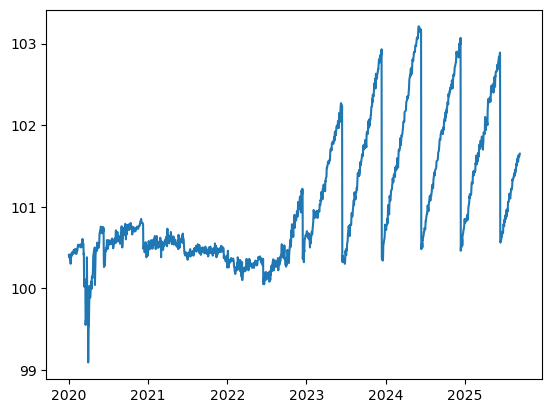

In [25]:
# plt.plot(df[['close','adjClose']].tail())


# plt.plot(df['close'])  # or 'Close' depending on what you want to chart
plt.plot(s)  # or 'Close' depending on what you want to chart
plt.show()
# plt.plot(ulvr['Close'])  # or 'Close' depending on what you want to chart